<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana3/Lab_PlanoInclinado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# LABORATORIO 2: GIROSCOPIO Y ORIENTACION
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# RUTA DE TRABAJO
# =====================================================

carpeta = "/content/drive/MyDrive/Datos_Lab1/"
archivo1 = "Lab2/Inclinacion.csv"
archivo2 = "Lab2/Velocity_1.csv"


ruta1 = os.path.join(carpeta, archivo1)
ruta2 = os.path.join(carpeta, archivo2)

# =====================================================
# CREAR CARPETA SI NO EXISTE
# =====================================================

os.makedirs(carpeta, exist_ok=True)

# ============================================================
# 1. CARGAR DATOS
# ============================================================
df_v = pd.read_csv(ruta2)
df_ang = pd.read_csv(ruta1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Columnas velocidad: Index(['Time (s)', 'Velocity (m/s)', 'Gyroscope y (rad/s)'], dtype='object')
Columnas inclinación: Index(['Time (s)', 'Tilt up/down (deg)', 'Tilt left/right (deg)'], dtype='object')
Ángulo promedio = 1.7137 grados
Ángulo promedio = 0.029910 rad


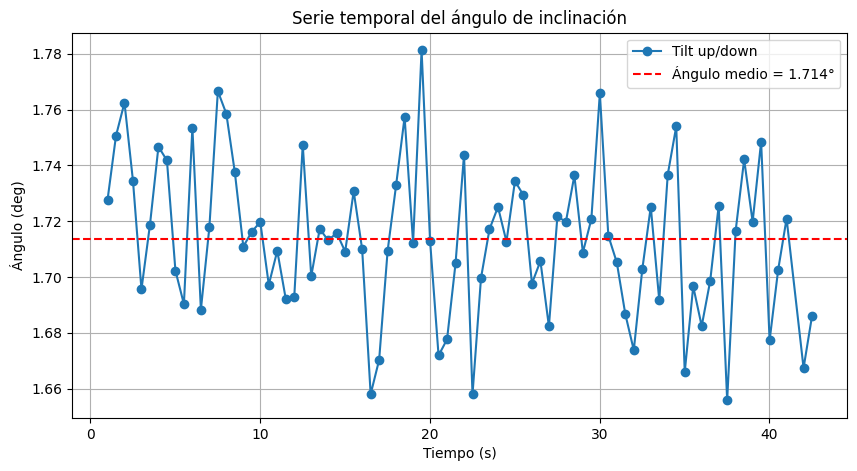

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Revisa nombres de columnas si hace falta
print("Columnas velocidad:", df_v.columns)
print("Columnas inclinación:", df_ang.columns)

t = df_v["Time (s)"].values
v = df_v["Velocity (m/s)"].values

theta_deg = df_ang["Tilt up/down (deg)"].values
theta_mean_deg = np.mean(theta_deg)
theta_mean_rad = np.deg2rad(theta_mean_deg)

print(f"Ángulo promedio = {theta_mean_deg:.4f} grados")
print(f"Ángulo promedio = {theta_mean_rad:.6f} rad")

# ============================================================
# 6. GRAFICAR INCLINACIÓN
# ============================================================
t_ang = df_ang["Time (s)"].values
theta_ud = df_ang["Tilt up/down (deg)"].values

plt.figure(figsize=(10, 5))
plt.plot(t_ang, theta_ud, 'o-', label="Tilt up/down")
plt.axhline(theta_mean_deg, color='r', linestyle='--',
            label=f"Ángulo medio = {theta_mean_deg:.3f}°")

plt.xlabel("Tiempo (s)")
plt.ylabel("Ángulo (deg)")
plt.title("Serie temporal del ángulo de inclinación")
plt.grid(True)
plt.legend()
ruta_fig1 = os.path.join(carpeta, "Angulo.pdf")
plt.savefig(ruta_fig1, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig1)

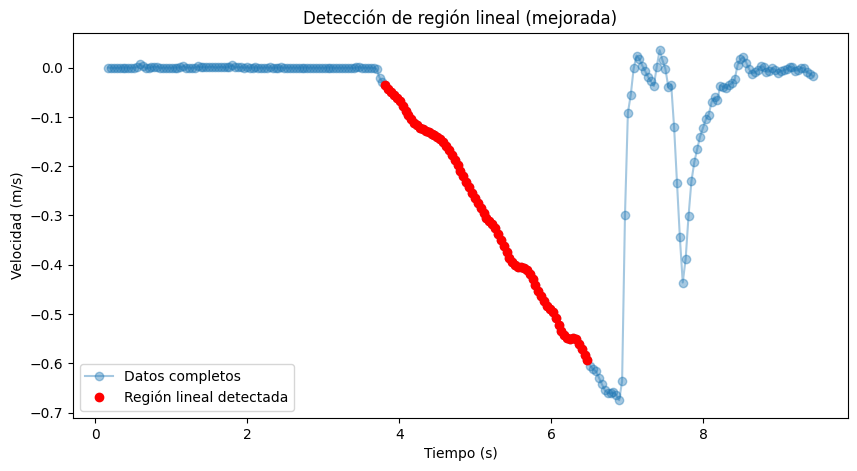

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# --------------------------------------------
# FUNCIÓN: calcular R² de ajuste lineal
# --------------------------------------------
def compute_r2(x, y):
    coef = np.polyfit(x, y, 1)
    y_fit = np.polyval(coef, x)
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot

# --------------------------------------------
# BÚSQUEDA DE REGIÓN LINEAL
# --------------------------------------------
window = 30   # tamaño de ventana (ajústalo)
r2_threshold = 0.97  # criterio fuerte de linealidad

mask = np.zeros(len(t), dtype=bool)

for i in range(len(t) - window):
    t_win = t[i:i+window]
    v_win = v[i:i+window]

    r2 = compute_r2(t_win, v_win)

    if r2 > r2_threshold:
        mask[i:i+window] = True

# --------------------------------------------
# FILTRADO FINAL, aca tener en cuenta el tiempo
# --------------------------------------------
maskfinal = mask & ( t < 6.5 ) & ( t > 3.8 )

t_lin = t[maskfinal]
v_lin = v[maskfinal]

# --------------------------------------------
# GRAFICAR
# --------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(t, v, 'o-', alpha=0.4, label="Datos completos")
plt.plot(t_lin, v_lin, 'ro', label="Región lineal detectada")

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.title("Detección de región lineal (mejorada)")
plt.legend()
ruta_fig2 = os.path.join(carpeta, "DatosFisicos.pdf")
plt.savefig(ruta_fig2, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig2)


=== AJUSTE LINEAL EN LA REGIÓN DE PENDIENTE NEGATIVA ===
Pendiente (aceleración experimental) = -0.217320 m/s^2
Intercepto = 0.814653 m/s
R^2 = 0.993609

=== ACELERACIONES TEÓRICAS SEGÚN EL ÁNGULO MEDIO ===
a_teórica (deslizamiento) = 0.293372 m/s^2
a_teórica (rodando, esfera maciza) = 0.209551 m/s^2
a_teórica (rodando, disco macizo)  = 0.195581 m/s^2
a_teórica (rodando, aro)           = 0.146686 m/s^2


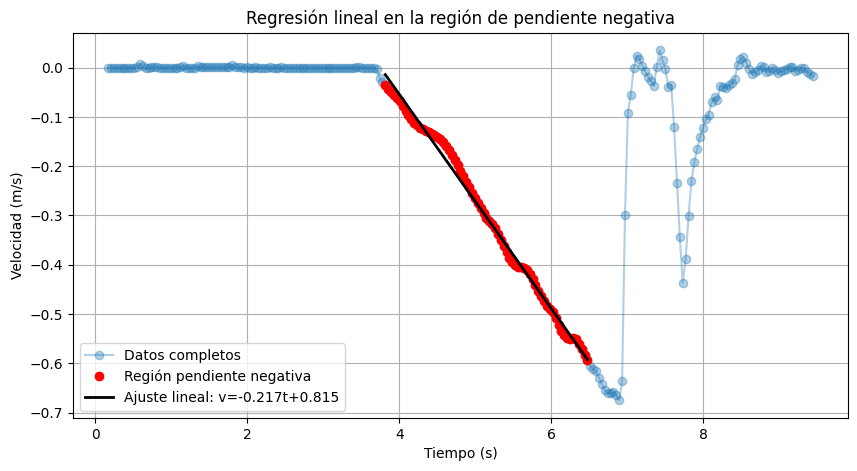

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ============================================================
# 3. AJUSTE LINEAL v(t) = a*t + b
# ============================================================
coef = np.polyfit(t_lin, v_lin, 1)
a_exp, b_exp = coef

v_fit = a_exp * t_lin + b_exp

# Calcular R^2
ss_res = np.sum((v_lin - v_fit)**2)
ss_tot = np.sum((v_lin - np.mean(v_lin))**2)
r2 = 1 - ss_res / ss_tot

print("\n=== AJUSTE LINEAL EN LA REGIÓN DE PENDIENTE NEGATIVA ===")
print(f"Pendiente (aceleración experimental) = {a_exp:.6f} m/s^2")
print(f"Intercepto = {b_exp:.6f} m/s")
print(f"R^2 = {r2:.6f}")

# ============================================================
# 4. ACELERACIÓN TEÓRICA A PARTIR DEL ÁNGULO
# ============================================================
g = 9.81

# Caso 1: deslizamiento sin rodar
a_slide = g * np.sin(theta_mean_rad)

# Caso 2: rodadura sin deslizamiento
# a = g sin(theta) / (1 + I/(mR^2))
#
# Ejemplos típicos:
# aro:      I = mR^2        -> beta = 1
# disco:    I = (1/2)mR^2   -> beta = 1/2
# esfera:   I = (2/5)mR^2   -> beta = 2/5
#
# Cambia beta según el objeto del experimento
beta_esfera = 2/5
beta_disco = 1/2
beta_aro = 1

a_roll_esfera = g * np.sin(theta_mean_rad) / (1 + beta_esfera)
a_roll_disco  = g * np.sin(theta_mean_rad) / (1 + beta_disco)
a_roll_aro    = g * np.sin(theta_mean_rad) / (1 + beta_aro)

# Aca de debe hacer una medición el momento de inercia del
# Los rollos de cinta + el celular. Sin embargo, dado que
# La practica es de cinemática, la practica busca es encontrar
# la relalción cinématica aproximada entre la velocidad del celular y el tiempo

print("\n=== ACELERACIONES TEÓRICAS SEGÚN EL ÁNGULO MEDIO ===")
print(f"a_teórica (deslizamiento) = {a_slide:.6f} m/s^2")
print(f"a_teórica (rodando, esfera maciza) = {a_roll_esfera:.6f} m/s^2")
print(f"a_teórica (rodando, disco macizo)  = {a_roll_disco:.6f} m/s^2")
print(f"a_teórica (rodando, aro)           = {a_roll_aro:.6f} m/s^2")

# ============================================================
# 5. GRAFICAR
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(t, v, 'o-', alpha=0.35, label="Datos completos")
plt.plot(t_lin, v_lin, 'ro', label="Región pendiente negativa")
plt.plot(t_lin, v_fit, 'k-', linewidth=2, label=f"Ajuste lineal: v={a_exp:.3f}t+{b_exp:.3f}")

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.title("Regresión lineal en la región de pendiente negativa")
plt.grid(True)
plt.legend()
ruta_fig3 = os.path.join(carpeta, "VelociadTiempo.pdf")
plt.savefig(ruta_fig3, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig3)


In [5]:
0.24/0.29

0.8275862068965517